# 1. Function Approximation


### 1
Feature engineering defines the representation ϕ(s),
while function approximation learns the parameters 𝑤 of a linear model that approximates the value function.
### 3
The policy improvement theorem assumes access to the true action-value function. 
With function approximation we only have an approximation. 
When the policy is improved using 
arg max 𝑄(𝑠,𝑎) the chosen action may not actually be better under the true action-value function. Thus the key inequality 
Qπ(s,π′(s))≥Vπ(s)
used in the proof no longer holds.
### 4
Using a neural network introduces function approximation, while TD(λ) uses bootstrapping, and the data from Mars Rover 1.0 corresponds to off-policy learning. The combination of these three elements is known as the deadly triad, which can lead to instability or divergence during training. As a result, learning the action-value function with a neural network in this setting may fail to converge.

# 2. Planning
### 3

The values are not identical.

MC gives

$$
v_\pi(uni) = 0.75, \qquad v_\pi(home) = 0
$$

TD gives

$$
v_\pi(uni) = 0.75, \qquad v_\pi(home) = 0.75\gamma
$$

They differ for home because MC uses the actually observed full return, while TD bootstraps from the estimated value of the next state. Since the only observed return from home was 0, MC estimates $v_\pi(home)=0$, whereas TD infers that home should have value $\gamma v_\pi(uni)$.

## 12. Comparison of DP with MC and TD

DP gives

$$
v_\pi(uni) = 0.75, \qquad v_\pi(home) = 0.75\gamma
$$

Previously:

MC:

$$
v_\pi(uni) = 0.75, \qquad v_\pi(home) = 0
$$

TD:

$$
v_\pi(uni) = 0.75, \qquad v_\pi(home) = 0.75\gamma
$$

So DP gives the same values as TD, but not the same as MC for home.

This is because DP and TD both use bootstrapping through the next-state value, while MC uses only sampled full returns.

## 15. Did the MC and TD values change?

The value of uni did not change:

$$
v_\pi(uni) = 0.75
$$

For home:

- MC changed from $0$ to $0.5\gamma$
- TD did not change and remained $0.75\gamma$

MC changed because it depends directly on sampled returns, and after adding simulated data there are more observations of home, including positive returns.

TD did not change because it bootstraps from $v_\pi(uni)$, and the transition structure of the problem remained the same.

# Exercise3 Monte Carlo Tree Search

### 1

The suggestion to use Monte Carlo Tree Search (MCTS) for a self-driving car could be reasonable, but its usefulness depends on several factors.

MCTS evaluates actions by building a search tree through simulated rollouts. It balances exploration and exploitation and can be effective for complex sequential decision problems. However, several considerations must be taken into account before applying it.

MCTS requires running many simulations to evaluate possible actions. Autonomous vehicles operate in real time, so the algorithm must be fast enough to produce decisions within milliseconds.

MCTS requires a simulator or model of the environment to generate rollouts. In real driving environments the dynamics, behaviour of other drivers, and sensor uncertainty may be difficult to model accurately.

Driving environments have large continuous state and action spaces. MCTS typically works best when the branching factor is manageable or when actions can be discretized.

Autonomous driving systems must guarantee safety. MCTS is stochastic and may produce suboptimal decisions if simulations are limited, which may be problematic in safety-critical systems.

Real traffic involves unpredictable agents (other drivers, pedestrians). Planning algorithms must handle partial observability and uncertainty, which increases the complexity of MCTS planning.

MCTS could be useful for high-level behaviour planning or decision making in simulated environments. However, its practicality depends on computational limits, model availability, state-space complexity, and safety requirements.

# Part II.
# Exercise4 Feature Engineering

### 2

In [18]:
import gymnasium as gym
import numpy as np

env = gym.make("MountainCar-v0")

# state bounds
pos_min, pos_max = env.observation_space.low[0], env.observation_space.high[0]
vel_min, vel_max = env.observation_space.low[1], env.observation_space.high[1]


discretization_steps = [0.1, 0.05, 0.02, 0.01, 0.005]
train_episodes = 1000

# ----------------HVILKE PARAMETERE? -----------------
eval_episodes = 20
n_actions = env.action_space.n
alpha = 0.1
gamma = 0.99
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay = 0.999


def discretize_with_delta(state, delta, pos_bins, vel_bins):
    pos, vel = state
    pos_i = int((pos - pos_min) / delta)
    vel_i = int((vel - vel_min) / delta)
    pos_i = np.clip(pos_i, 0, pos_bins - 1)
    vel_i = np.clip(vel_i, 0, vel_bins - 1)
    return pos_i, vel_i


results = {}

for delta in discretization_steps:
    pos_bins = int((pos_max - pos_min) / delta)
    vel_bins = int((vel_max - vel_min) / delta)
    Q = np.zeros((pos_bins, vel_bins, n_actions))

    epsilon_delta = epsilon_start

    for episode in range(train_episodes):
        state, _ = env.reset()
        s = discretize_with_delta(state, delta, pos_bins, vel_bins)
        done = False

        while not done:
            if np.random.rand() < epsilon_delta:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[s])

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            s_next = discretize_with_delta(next_state, delta, pos_bins, vel_bins)

            best_next = 0 if done else np.max(Q[s_next])
            Q[s + (action,)] += alpha * (
                reward + gamma * best_next - Q[s + (action,)]
            )

            s = s_next

        epsilon_delta = max(epsilon_end, epsilon_delta * epsilon_decay)

    eval_rewards = []

    for epsiode in range(eval_episodes):
        state, _ = env.reset()
        s = discretize_with_delta(state, delta, pos_bins, vel_bins)
        total_reward = 0
        done = False

        while not done:
            action = np.argmax(Q[s])
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            s = discretize_with_delta(next_state, delta, pos_bins, vel_bins)
            total_reward += reward

        eval_rewards.append(total_reward)

    results[delta] = np.mean(eval_rewards)

print(results)

{0.1: -200.0, 0.05: -200.0, 0.02: -200.0, 0.01: -200.0, 0.005: -200.0}


Different discretization steps Δ can affect the learned policy.

- Large Δ gives a coarse state representation and usually learns faster, but it may miss useful detail.
- Small Δ gives a finer representation, but it increases the number of discrete states and often needs more training.

In my experiment, the evaluated returns were {0.1: -200.0, 0.05: -200.0, 0.02: -200.0, 0.01: -200.0, 0.005: -200.0}.
This means that all tested values of Δ performed identically poorly.

So, in this setup, the results do not show a meaningful performance difference between the tested discretization steps. The limiting factor appears to be the overall training setup and task difficulty, not Δ alone.

### 3 Other feature engineering approaches

Other feature engineering techniques could improve learning performance in MountainCar:

- **Tile coding**: overlapping tilings of the state space provide a richer representation and allow generalization across nearby states.
- **Radial basis functions (RBF)**: continuous features centered at different regions of the state space.
- **Polynomial features**: combining position and velocity into higher-order features.
- **Fourier basis features**: commonly used in continuous control problems.

These approaches allow the agent to generalize across states without requiring a very fine discretization of the state space.

# Exercise5 Planning
### 4

Trajectory:
[(13, 5), (13, 9), (10, 19), (8, 23), (7, 26), (2, 29), (3, 34), (4, 36), (5, 38), (6, 34), (7, 36), (8, 55), (9, 58), (10, 61), (13, 58), (14, 54)]


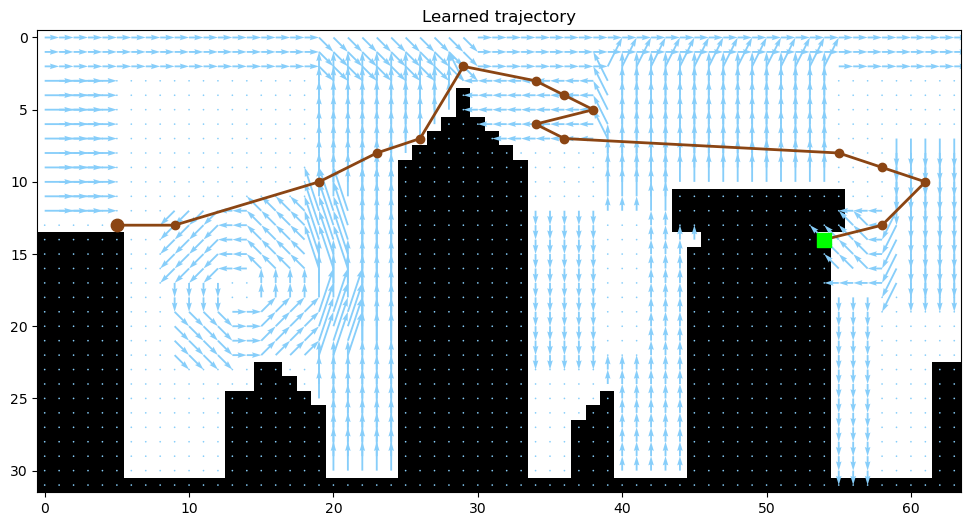


Comparison across planning steps:
planning_steps=0: mean length=210.00, std=128.69
planning_steps=5: mean length=16.00, std=0.00
planning_steps=10: mean length=16.00, std=0.00
planning_steps=20: mean length=16.00, std=0.00


In [19]:
import numpy as np
import random
from collections import defaultdict
import matplotlib.pyplot as plt
# Load transitions from power_flight.txt
def load_power_flight(path):
    data = []

    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # remove common separators if present
            line = line.replace("(", "").replace(")", "").replace(",", " ")
            parts = line.split()

            if len(parts) != 6:
                raise ValueError(f"Unexpected line format: {line}")

            i, j, a, r, ip, jp = map(int, parts)

            # convert states from 1-indexed to 0-indexed
            s = (i - 1, j - 1)
            s_next = (ip - 1, jp - 1)

            data.append((s, a, r, s_next))

    return data


#1
# Build learned model M-hat from data
# Model stores empirical transition probabilities and rewards
def build_model(data):
    transition_counts = defaultdict(lambda: defaultdict(int))
    reward_sums = defaultdict(float)
    sa_counts = defaultdict(int)

    states = set()
    actions = set()

    for s, a, r, s_next in data:
        transition_counts[(s, a)][s_next] += 1
        reward_sums[(s, a)] += r
        sa_counts[(s, a)] += 1

        states.add(s)
        states.add(s_next)
        actions.add(a)

    model = {}

    for sa, next_counts in transition_counts.items():
        total = sa_counts[sa]
        reward_mean = reward_sums[sa] / total

        probs = {}
        for s_next, c in next_counts.items():
            probs[s_next] = c / total

        model[sa] = {
            "reward": reward_mean,
            "transitions": probs,
        }

    return model, states, sorted(actions)

# Sample from learned model

def sample_from_model(model, s, a):
    entry = model[(s, a)]
    reward = entry["reward"]
    next_states = list(entry["transitions"].keys())
    probs = list(entry["transitions"].values())

    idx = np.random.choice(len(next_states), p=probs)
    s_next = next_states[idx]

    return reward, s_next



# Dyna-Q on learned model
# Since data are offline, we use observed state-action pairs as "real experience"
# and add planning updates from the learned model.

def epsilon_greedy(Q, s, available_actions, epsilon):
    if random.random() < epsilon:
        return random.choice(available_actions)
    qvals = [Q[(s, a)] for a in available_actions]
    return available_actions[int(np.argmax(qvals))]


def dyna_q_from_model(
    model,
    observed_sa,
    actions,
    goal_state,
    alpha=0.1,
    gamma=0.99,
    epsilon=0.1,
    planning_steps=10,
    episodes=5000,
):
    Q = defaultdict(float)

    observed_sa_list = list(observed_sa)
    observed_states = sorted({s for s, _ in observed_sa_list})

    for ep in range(episodes):
        # start from a random observed state-action source state
        s = random.choice(observed_states)

        done = False
        step_count = 0

        while not done and step_count < 500:
            feasible_actions = [a for a in actions if (s, a) in model]
            if not feasible_actions:
                break

            a = epsilon_greedy(Q, s, feasible_actions, epsilon)
            r, s_next = sample_from_model(model, s, a)

            next_actions = [ap for ap in actions if (s_next, ap) in model]
            max_next = max([Q[(s_next, ap)] for ap in next_actions], default=0.0)

            Q[(s, a)] += alpha * (r + gamma * max_next - Q[(s, a)])

            # planning updates
            for _ in range(planning_steps):
                sp, ap = random.choice(observed_sa_list)
                rp, sp_next = sample_from_model(model, sp, ap)

                next_actions_p = [app for app in actions if (sp_next, app) in model]
                max_next_p = max([Q[(sp_next, app)] for app in next_actions_p], default=0.0)

                Q[(sp, ap)] += alpha * (rp + gamma * max_next_p - Q[(sp, ap)])

            s = s_next
            done = (s == goal_state) or (r == 1)
            step_count += 1

    return Q


# Extract greedy policy


def greedy_policy(Q, model, actions):
    states = {s for s, _ in model.keys()}
    policy = {}

    for s in states:
        feasible_actions = [a for a in actions if (s, a) in model]
        if not feasible_actions:
            continue

        qvals = [Q[(s, a)] for a in feasible_actions]
        policy[s] = feasible_actions[int(np.argmax(qvals))]

    return policy


# Roll out policy inside learned model to get an "optimal" trajectory
def rollout_policy(policy, model, start_state, goal_state, max_steps=200):
    trajectory = [start_state]
    s = start_state

    for _ in range(max_steps):
        if s == goal_state:
            break
        if s not in policy:
            break

        a = policy[s]

        # choose most likely next state for deterministic plotting
        transitions = model[(s, a)]["transitions"]
        s_next = max(transitions, key=transitions.get)

        trajectory.append(s_next)
        s = s_next

        if s == goal_state:
            break

    return trajectory


# Plot trajectory

def plot_trajectory(trajectory, start_state, goal_state):
    skyline = np.genfromtxt("skyscraper/envs/skyline.txt")
    horizontal_wind = np.genfromtxt("skyscraper/envs/horizontal_wind.txt")
    vertical_wind = np.genfromtxt("skyscraper/envs/vertical_wind.txt")
    rows, cols = skyline.shape
    X, Y = np.meshgrid(np.arange(cols), np.arange(rows))

    xs = [s[1] for s in trajectory]
    ys = [s[0] for s in trajectory]

    plt.figure(figsize=(14, 6))

    # buildings
    plt.imshow(skyline, cmap="gray", origin="upper")

    # winds
    plt.quiver(
        X, Y,
        horizontal_wind, vertical_wind,
        color="lightskyblue",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.002
    )
    # trajectory
    plt.plot(xs, ys, color="saddlebrown", marker="o", linewidth=2)

    plt.scatter(start_state[1], start_state[0], color="saddlebrown", s=80, zorder=3)
    plt.scatter(goal_state[1], goal_state[0], color="lime", marker="s", s=100, zorder=3)
    plt.xlim(-0.5, cols - 0.5)
    plt.ylim(rows - 0.5, -0.5)
    plt.title("Learned trajectory")
    plt.show()


# Compare different numbers of planning steps
def evaluate_planning_steps(
    model,
    observed_sa,
    actions,
    start_state,
    goal_state,
    planning_values=(0, 5, 10, 20, 50),
    runs=5,
    episodes=3000,
):
    results = {}

    for p in planning_values:
        lengths = []

        for _ in range(runs):
            Q = dyna_q_from_model(
                model=model,
                observed_sa=observed_sa,
                actions=actions,
                goal_state=goal_state,
                alpha=0.1,
                gamma=0.99,
                epsilon=0.1,
                planning_steps=p,
                episodes=episodes,
            )

            policy = greedy_policy(Q, model, actions)
            traj = rollout_policy(policy, model, start_state, goal_state, max_steps=300)
            lengths.append(len(traj))

        results[p] = {
            "mean_trajectory_length": float(np.mean(lengths)),
            "std_trajectory_length": float(np.std(lengths)),
        }

    return results

path = "powered_flight.txt"

# assignment states:
# start = (13, 5), goal = (14, 54) in 0-indexed environment description
start_state = (13, 5)
goal_state = (14, 54)

data = load_power_flight(path)
model, states, actions = build_model(data)
observed_sa = set((s, a) for s, a, _, _ in data)

# Keep notebook defaults moderate so the cell finishes in reasonable time.
main_training_episodes = 1500
main_planning_steps = 10
comparison_planning_values = (0, 5, 10, 20)
comparison_runs = 3
comparison_episodes = 1000

# Learn Q with Dyna-Q
Q = dyna_q_from_model(
    model=model,
    observed_sa=observed_sa,
    actions=actions,
    goal_state=goal_state,
    alpha=0.1,
    gamma=0.99,
    epsilon=0.1,
    planning_steps=main_planning_steps,
    episodes=main_training_episodes,
)

policy = greedy_policy(Q, model, actions)
trajectory = rollout_policy(policy, model, start_state, goal_state)

print("Trajectory:")
print(trajectory)

plot_trajectory(trajectory, start_state, goal_state)

# Compare planning steps
results = evaluate_planning_steps(
    model=model,
    observed_sa=observed_sa,
    actions=actions,
    start_state=start_state,
    goal_state=goal_state,
    planning_values=comparison_planning_values,
    runs=comparison_runs,
    episodes=comparison_episodes,
)

print("\nComparison across planning steps:")
for p, stats in results.items():
    print(
        f"planning_steps={p}: "
        f"mean length={stats['mean_trajectory_length']:.2f}, "
        f"std={stats['std_trajectory_length']:.2f}"
    )

Comparison across planning steps:
planning_steps=0: mean score=0.00, std score=0.00, best score=0.00, mean steps=300.00
planning_steps=3: mean score=1.00, std score=0.00, best score=1.00, mean steps=15.00
planning_steps=5: mean score=1.00, std score=0.00, best score=1.00, mean steps=15.00
planning_steps=10: mean score=1.00, std score=0.00, best score=1.00, mean steps=15.00


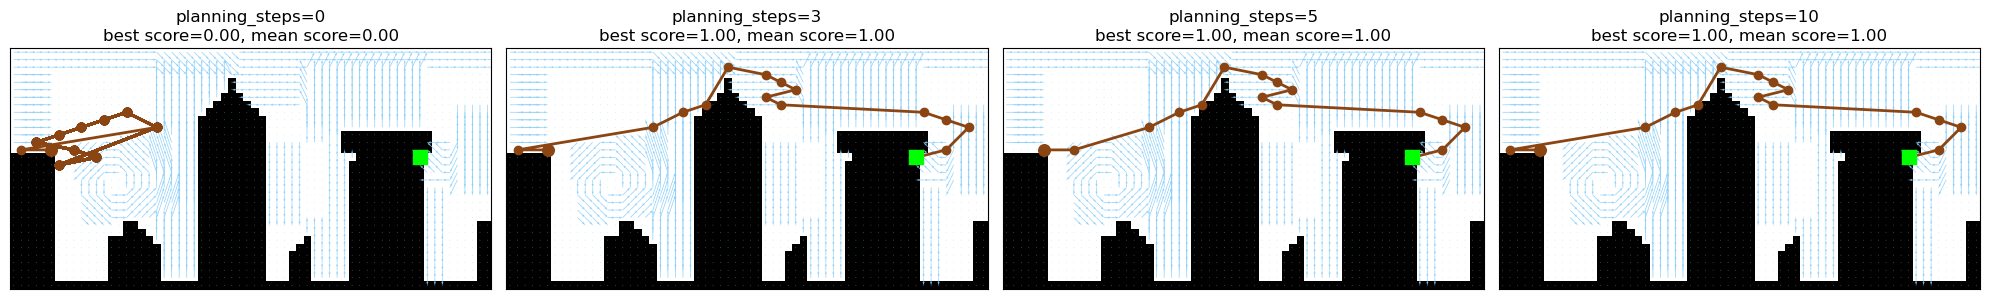

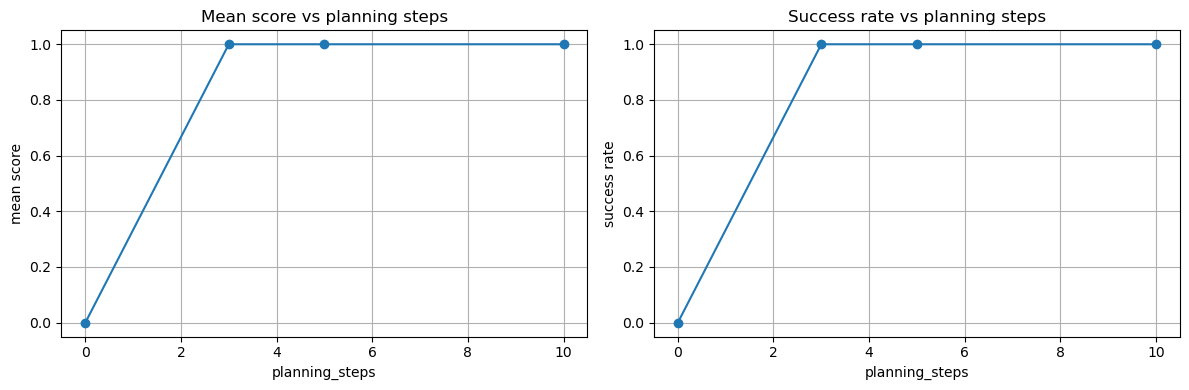

In [20]:
# Roll out a greedy policy inside the learned model and score it.
def rollout_policy(policy, model, start_state, goal_state, max_steps=300):
    trajectory = [start_state]
    s = start_state
    cumulative_return = 0.0
    success = s == goal_state

    for _ in range(max_steps):
        if success or s not in policy:
            break

        a = policy[s]
        entry = model[(s, a)]
        reward = entry["reward"]
        transitions = entry["transitions"]

        # Deterministic rollout for plotting: use the most likely next state.
        s_next = max(transitions, key=transitions.get)

        trajectory.append(s_next)
        cumulative_return += reward
        s = s_next
        success = (s == goal_state) or (reward == 1)

    return trajectory, cumulative_return, success


def plot_trajectory(trajectory, start_state, goal_state, title, score_text, ax=None):
    skyline = np.loadtxt("skyscraper/envs/skyline.txt", dtype=int)
    horizontal_wind = np.loadtxt("skyscraper/envs/horizontal_wind.txt", dtype=float)
    vertical_wind = np.loadtxt("skyscraper/envs/vertical_wind.txt", dtype=float)

    rows, cols = skyline.shape
    x_coords, y_coords = np.meshgrid(np.arange(cols), np.arange(rows))

    xs = [s[1] for s in trajectory]
    ys = [s[0] for s in trajectory]

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))

    ax.imshow(skyline, cmap="gray", origin="upper")

    ax.quiver(
        x_coords,
        y_coords,
        horizontal_wind,
        vertical_wind,
        color="lightskyblue",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.0015,
        alpha=0.9,
    )

    ax.plot(xs, ys, color="saddlebrown", marker="o", linewidth=2)
    ax.scatter(start_state[1], start_state[0], s=70, color="saddlebrown", zorder=3)
    ax.scatter(goal_state[1], goal_state[0], s=90, marker="s", color="lime", zorder=3)

    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(rows - 0.5, -0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{title}\n{score_text}")


def evaluate_planning_steps(
    model,
    observed_sa,
    actions,
    start_state,
    goal_state,
    planning_values=(0, 5, 10, 20, 50),
    runs=5,
    episodes=3000,
):
    results = {}

    for p in planning_values:
        returns = []
        steps = []
        successes = []
        best_rollout = None

        for _ in range(runs):
            Q = dyna_q_from_model(
                model=model,
                observed_sa=observed_sa,
                actions=actions,
                goal_state=goal_state,
                alpha=0.1,
                gamma=0.99,
                epsilon=0.1,
                planning_steps=p,
                episodes=episodes,
            )

            policy = greedy_policy(Q, model, actions)
            traj, cumulative_return, success = rollout_policy(
                policy, model, start_state, goal_state, max_steps=300
            )

            returns.append(cumulative_return)
            steps.append(len(traj) - 1)
            successes.append(int(success))

            if best_rollout is None or cumulative_return > best_rollout[1]:
                best_rollout = (traj, cumulative_return, success)

        results[p] = {
            "mean_return": float(np.mean(returns)),
            "std_return": float(np.std(returns)),
            "mean_steps": float(np.mean(steps)),
            "success_rate": float(np.mean(successes)),
            "best_trajectory": best_rollout[0],
            "best_return": float(best_rollout[1]),
            "best_success": bool(best_rollout[2]),
        }

    return results


def plot_planning_comparison(results, start_state, goal_state):
    planning_values = list(results.keys())

    fig, axes = plt.subplots(1, len(planning_values), figsize=(5 * len(planning_values), 5))
    if len(planning_values) == 1:
        axes = [axes]

    for ax, planning_steps in zip(axes, planning_values):
        stats = results[planning_steps]
        score_text = (
        f"best score={stats['best_return']:.2f}, "
        f"mean score={stats['mean_return']:.2f}"
        )


        plot_trajectory(
            stats["best_trajectory"],
            start_state,
            goal_state,
            title=f"planning_steps={planning_steps}",
            score_text=score_text,
            ax=ax,
        )

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    mean_returns = [results[p]["mean_return"] for p in planning_values]
    success_rates = [results[p]["success_rate"] for p in planning_values]

    axes[0].plot(planning_values, mean_returns, marker="o")
    axes[0].set_title("Mean score vs planning steps")
    axes[0].set_ylabel("mean score")
    axes[0].set_xlabel("planning_steps")
    axes[0].grid(True)

    axes[1].plot(planning_values, success_rates, marker="o")
    axes[1].set_title("Success rate vs planning steps")
    axes[1].set_xlabel("planning_steps")
    axes[1].set_ylabel("success rate")
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


path = "powered_flight.txt"

start_state = (13, 5)
goal_state = (14, 54)

data = load_power_flight(path)
model, states, actions = build_model(data)
observed_sa = set((s, a) for s, a, _, _ in data)

comparison_planning_values = (0,3,5, 10)
comparison_runs = 4
comparison_episodes = 300


results = evaluate_planning_steps(
    model=model,
    observed_sa=observed_sa,
    actions=actions,
    start_state=start_state,
    goal_state=goal_state,
    planning_values=comparison_planning_values,
    runs=comparison_runs,
    episodes=comparison_episodes,
)

print("Comparison across planning steps:")
for p, stats in results.items():
    print(
        f"planning_steps={p}: "
        f"mean score={stats['mean_return']:.2f}, "
        f"std score={stats['std_return']:.2f}, "
        f"best score={stats['best_return']:.2f}, "
        f"mean steps={stats['mean_steps']:.2f}"
    )


plot_planning_comparison(results, start_state, goal_state)
